# Train a CNN+FNN to output the move direction (dx, dy)

The model reads the fox's 2-channel egocentric view — **terrain** + **entity** (the sheep) —
and **outputs the `(dx, dy)` heading to move**, exactly the quantity `RuleBrain` produces.

We take one view per scene from `fox_vision_dataset.csv` and regress toward the unit vector
pointing at the sheep. On held-out scenes we check the output heading points at the sheep.

In [8]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

_here = Path.cwd()
REPO = next((c for c in [_here, *_here.parents]
             if (c / "config.py").exists() and (c / "sim").is_dir()), _here)
DATA_PATH = REPO / "notebooks" / "vision" / "fox" / "fox_vision_dataset.csv"

torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| data:", DATA_PATH)

device: cuda | data: c:\Users\afree\Desktop\ecosystem\notebooks\vision\fox\fox_vision_dataset.csv


In [9]:
df = pd.read_csv(DATA_PATH)
WIN = int(round(int(df.columns.str.startswith("t_").sum()) ** 0.5))
t_cols = [f"t_{i}" for i in range(WIN*WIN)]
e_cols = [f"e_{i}" for i in range(WIN*WIN)]

# One view per scene (the generator wrote several candidate-heading rows per scene, but the
# pixels are identical within a scene). Target = unit vector pointing AT the sheep -- the
# (dx, dy) heading the fox should move, the same quantity RuleBrain outputs.
one = df.drop_duplicates("scenario_id", keep="first").reset_index(drop=True)
terr = one[t_cols].to_numpy(np.float32).reshape(-1, WIN, WIN)
enti = one[e_cols].to_numpy(np.float32).reshape(-1, WIN, WIN)
X = np.stack([terr, enti], axis=1)                             # (S, 2, WIN, WIN)
toward = one[["sheep_dx", "sheep_dy"]].to_numpy(np.float32)
toward /= np.linalg.norm(toward, axis=1, keepdims=True) + 1e-9  # unit (dx, dy) target
print("scenes:", len(one), "| X:", X.shape, "| target (dx,dy):", toward.shape)

scenes: 1000 | X: (1000, 2, 25, 25) | target (dx,dy): (1000, 2)


In [10]:
# Random train/val split over scenes (one row per scene -> nothing to leak).
rng = np.random.default_rng(0)
order = rng.permutation(len(X))
n_val = max(1, int(0.2 * len(X)))
va, tr = order[:n_val], order[n_val:]
Xtr, ytr = torch.tensor(X[tr]), torch.tensor(toward[tr])
Xva, yva = torch.tensor(X[va]), torch.tensor(toward[va])
print(f"train scenes {len(Xtr)} | val scenes {len(Xva)}")

train scenes 800 | val scenes 200


In [11]:
class FoxVisionNet(nn.Module):
    """CNN over the 2-channel view -> FNN -> the (dx, dy) heading to move (like RuleBrain)."""
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(2, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(6),
            nn.Flatten(),
        )
        self.fnn = nn.Sequential(
            nn.Linear(32*6*6, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 2),                    # -> (dx, dy); normalized to a unit heading
        )
    def forward(self, grid):
        return self.fnn(self.cnn(grid))

model = FoxVisionNet().to(device)
print(model)
print("trainable params:", sum(p.numel() for p in model.parameters()))

FoxVisionNet(
  (cnn): Sequential(
    (0): Conv2d(2, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): AdaptiveAvgPool2d(output_size=6)
    (8): Flatten(start_dim=1, end_dim=-1)
  )
  (fnn): Sequential(
    (0): Linear(in_features=1152, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)
trainable params: 170162


In [12]:
def unit(v):
    return v / (v.norm(dim=1, keepdim=True) + 1e-9)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
Xtr_d, ytr_d = Xtr.to(device), ytr.to(device)
Xva_d, yva_d = Xva.to(device), yva.to(device)

EPOCHS, BATCH = 60, 64
n = len(Xtr_d)
for ep in range(1, EPOCHS + 1):
    model.train()
    perm = torch.randperm(n, device=device)
    tot = 0.0
    for i in range(0, n, BATCH):
        b = perm[i:i+BATCH]
        pred = unit(model(Xtr_d[b]))
        loss = (1.0 - (pred * ytr_d[b]).sum(1)).mean()      # 1 - cosine similarity
        opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item() * len(b)
    if ep == 1 or ep % 5 == 0:
        model.eval()
        with torch.no_grad():
            vcos = (unit(model(Xva_d)) * yva_d).sum(1).mean().item()
        print(f"epoch {ep:2d}  train_loss {tot/n:.4f}   val cos(pred,true) {vcos:.4f}")

epoch  1  train_loss 1.0279   val cos(pred,true) 0.0158
epoch  5  train_loss 0.8886   val cos(pred,true) 0.1662
epoch 10  train_loss 0.0030   val cos(pred,true) 0.9966
epoch 15  train_loss 0.0023   val cos(pred,true) 0.9969
epoch 20  train_loss 0.0021   val cos(pred,true) 0.9968
epoch 25  train_loss 0.0019   val cos(pred,true) 0.9966
epoch 30  train_loss 0.0017   val cos(pred,true) 0.9964
epoch 35  train_loss 0.0016   val cos(pred,true) 0.9964
epoch 40  train_loss 0.0014   val cos(pred,true) 0.9964
epoch 45  train_loss 0.0014   val cos(pred,true) 0.9959
epoch 50  train_loss 0.0012   val cos(pred,true) 0.9956
epoch 55  train_loss 0.0011   val cos(pred,true) 0.9953
epoch 60  train_loss 0.0009   val cos(pred,true) 0.9949


## The proof — the output heading points at the sheep

The model's raw output **is** the `(dx, dy)` heading (we just normalize it to unit length).
On held-out scenes it should align with the direction to the sheep — cosine → +1, small
angular error.

held-out scenes: 200
mean cosine(pred, toward-sheep): +0.995
within 20 deg of sheep:          99.5%
median heading error:            2.6 deg


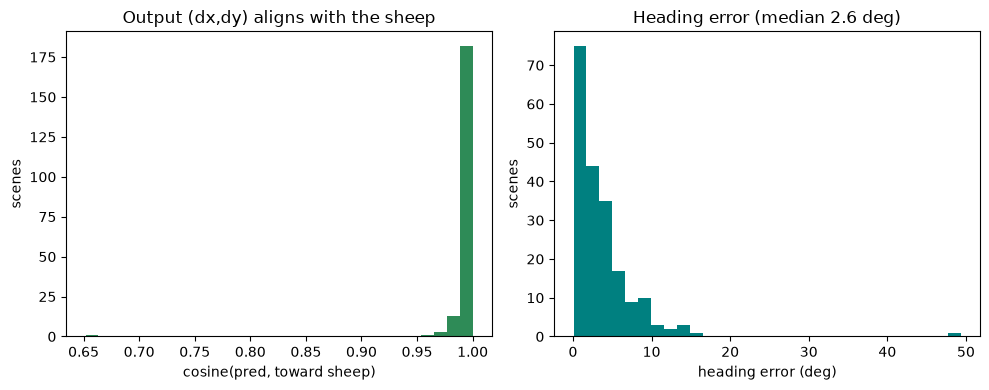

In [13]:
model.eval()
with torch.no_grad():
    pred = unit(model(Xva_d)).cpu().numpy()      # <- the model's (dx, dy) output

true = toward[va]
cos = (pred * true).sum(1)
ang = np.degrees(np.arccos(np.clip(cos, -1, 1)))
print(f"held-out scenes: {len(pred)}")
print(f"mean cosine(pred, toward-sheep): {cos.mean():+.3f}")
print(f"within 20 deg of sheep:          {np.mean(ang <= 20)*100:.1f}%")
print(f"median heading error:            {np.median(ang):.1f} deg")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(cos, bins=30, color="seagreen")
ax[0].set_xlabel("cosine(pred, toward sheep)"); ax[0].set_ylabel("scenes")
ax[0].set_title("Output (dx,dy) aligns with the sheep")
ax[1].hist(ang, bins=30, color="teal")
ax[1].set_xlabel("heading error (deg)"); ax[1].set_ylabel("scenes")
ax[1].set_title(f"Heading error (median {np.median(ang):.1f} deg)")
plt.tight_layout(); plt.show()

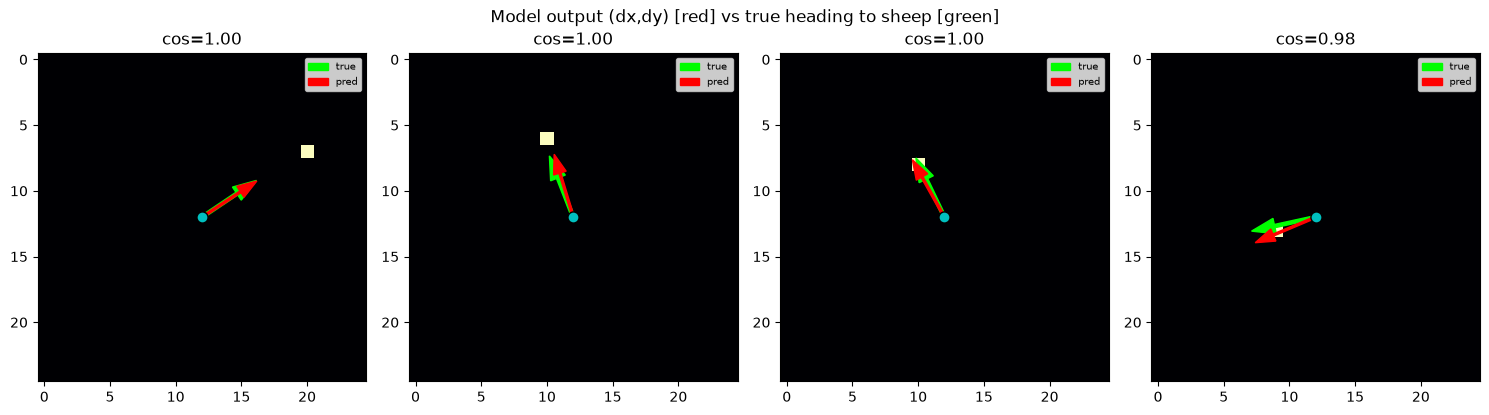

In [14]:
# Predicted (dx,dy) [red] vs the true toward-sheep heading [green] on a few held-out views.
pick = np.random.default_rng(1).choice(len(va), size=4, replace=False)
c = WIN // 2
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
with torch.no_grad():
    for a, pi in zip(axes, pick):
        gi = va[pi]
        p = unit(model(torch.tensor(X[gi:gi+1]).to(device))).cpu().numpy()[0]
        tw = toward[gi]
        a.imshow(X[gi, 1], origin="upper", cmap="magma")     # entity channel (sheep)
        a.plot(c, c, "co", ms=8, mec="k")
        a.arrow(c, c, tw[0]*5, tw[1]*5, color="lime", width=0.25, head_width=1.2,
                length_includes_head=True, label="true")
        a.arrow(c, c, p[0]*5, p[1]*5, color="red", width=0.16, head_width=1.0,
                length_includes_head=True, label="pred")
        a.set_title(f"cos={float(p @ tw):.2f}"); a.legend(loc="upper right", fontsize=7)
fig.suptitle("Model output (dx,dy) [red] vs true heading to sheep [green]")
plt.tight_layout(); plt.show()

## Conclusion

The CNN+FNN **outputs the `(dx, dy)` move direction directly** — the same quantity
`RuleBrain` produces — from the fox's terrain + entity view alone. On held-out scenes the
output heading points at the sheep with a small angular error, so a learned brain can follow
(and chase / catch) the entity and drop in behind the `Brain.decide(obs) → act` contract.

In [16]:
torch.save(model.state_dict(), "foxvision.pth")